# Import all library and data

##### Datsets Info: Sample Data Set containing data and showing customers left last month

In [140]:
import pandas as pd
import sklearn as sk
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### 1.Data Analysis

In [141]:
teleco_based_data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [142]:
teleco_based_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [143]:
teleco_based_data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [144]:
teleco_based_data.shape

(7043, 21)

In [145]:
teleco_based_data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [146]:
teleco_based_data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [147]:
# Check the description statistics of numeric value
teleco_based_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


75% percent of customer have tenure less than 55

Average Monthly  charges is 64.76$

Senior Citizen is Catagorial Data hence distribution of data is not proper

Text(0.5, 1.0, 'Count of Target variable per Category')

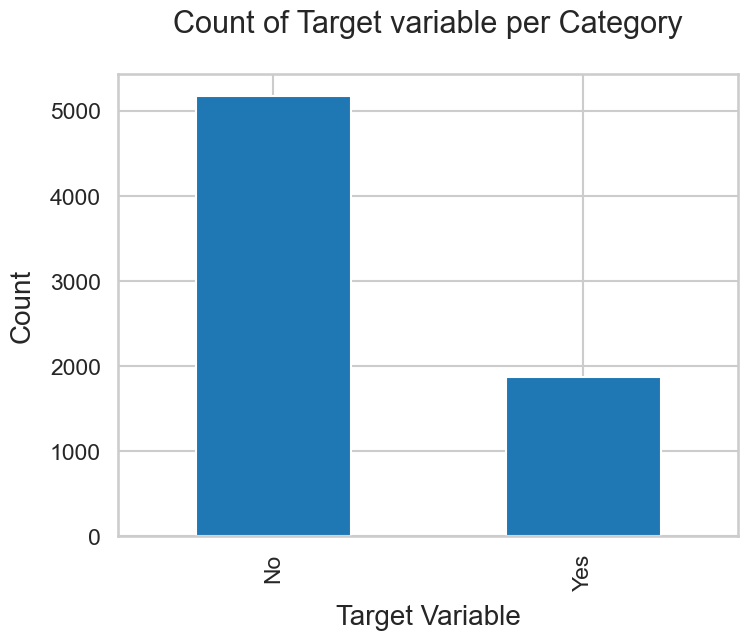

In [148]:
teleco_based_data['Churn'].value_counts().plot(kind='bar',figsize=(8,6))
plt.xlabel('Target Variable',labelpad=10)
plt.ylabel('Count',labelpad=10)
plt.title("Count of Target variable per Category")

In [149]:
100*teleco_based_data['Churn'].value_counts()/len(teleco_based_data['Churn'])

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

We understand that:

Data is highly imbalance, ratio = 73.46

So we analyse the data with other features

In [150]:
teleco_based_data.info(verbose= True) # Provide the info Non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [151]:
import matplotlib.ticker as mticks

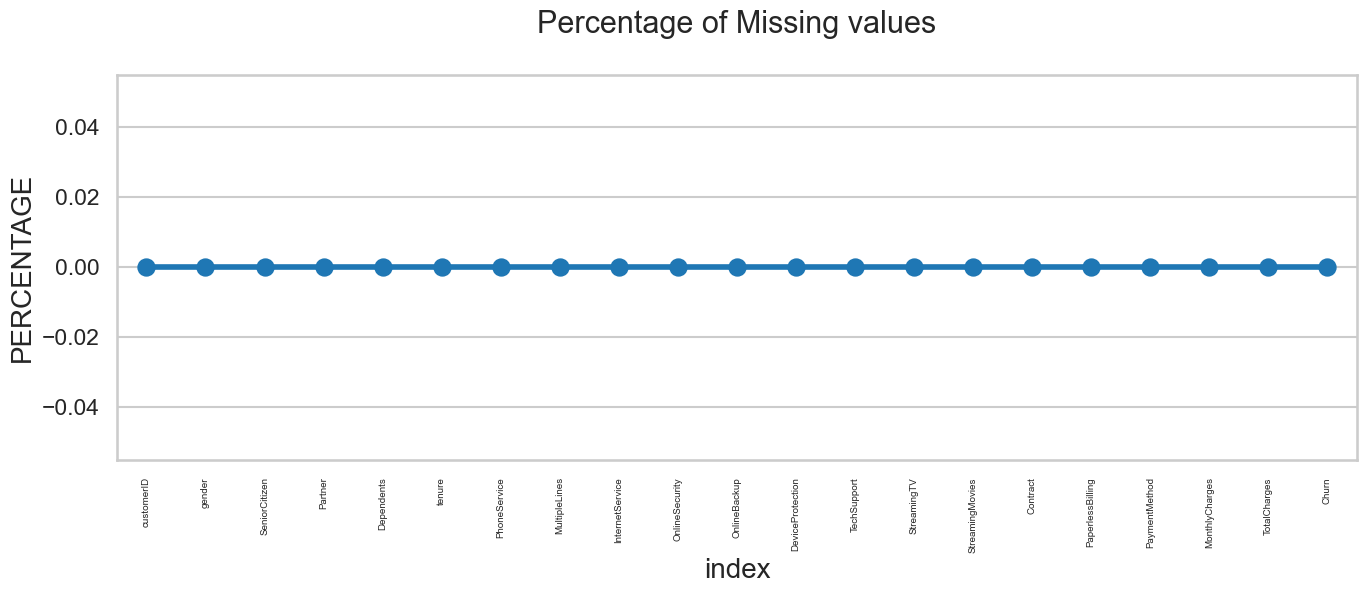

In [152]:
missing = pd.DataFrame((teleco_based_data.isnull().sum())*100/teleco_based_data.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index',y=0,data=missing)
plt.xticks(rotation =90,fontsize =7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

### Missing data intuition
There is no missing data(i.e null valu) in the coloumn 

### General Thumb Rules:

* For features with less missing values- can use regression to predict the missing values or fill with the mean of the values present, depending on the feature.
* For features with very high number of missing values- it is better to drop those columns as they give very less insight on analysis.
* As there's no thumb rule on what criteria do we delete the columns with high number of missing values, but generally you can delete the columns, if you have more than 30-40% of missing values. But again there's a catch here, for example, Is_Car & Car_Type, People having no cars, will obviously have Car_Type as NaN (null), but that doesn't make this column useless, so decisions has to be taken wisely.

### 2.Data CLeaning

#### 1. Data Copy

In [153]:
teleco_copy_data = teleco_based_data.copy()

#### 2. Coversion of obj variable into numeric

In [154]:
teleco_copy_data.TotalCharges = pd.to_numeric(teleco_copy_data.TotalCharges,errors='coerce')
teleco_copy_data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [155]:
teleco_copy_data.loc[teleco_copy_data ['TotalCharges'].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Amount of null data is 0.15%.

Therefore it is okay to drop that data

In [156]:
#Removing null data
teleco_copy_data.dropna(how='any',inplace=True)

Tenure relation with churn

In [157]:
print(teleco_copy_data['tenure'].max())

72


Tenure max value is 72. While comparing with churn it will be large amount of x data.

Therefore we divide that data into categorial group for easy understanding

In [158]:
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]
teleco_copy_data['tenure_group'] = pd.cut(teleco_copy_data.tenure, range(1, 81, 12), right=False, labels=labels)

In [159]:
teleco_copy_data['tenure_group'].value_counts()

tenure_group
1 - 12     2175
61 - 72    1407
13 - 24    1024
25 - 36     832
49 - 60     832
37 - 48     762
Name: count, dtype: int64

In [160]:
teleco_copy_data.drop(columns=['customerID','tenure'], axis=1, inplace=True)

In [161]:
teleco_copy_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


### 3.Data exploration

Plot each distributer with individual by churn by using univariate analysis

To understand what is relation betweeen the data and also to solve few issues:


Q1 What is relation between tenure and churn?  
Q2 Do gender and partner matter really matter?  
Q.3 Is dependency and partner feauters are corelated?  
Q4  Do internet Service matter?  

#### Univariate Analysis

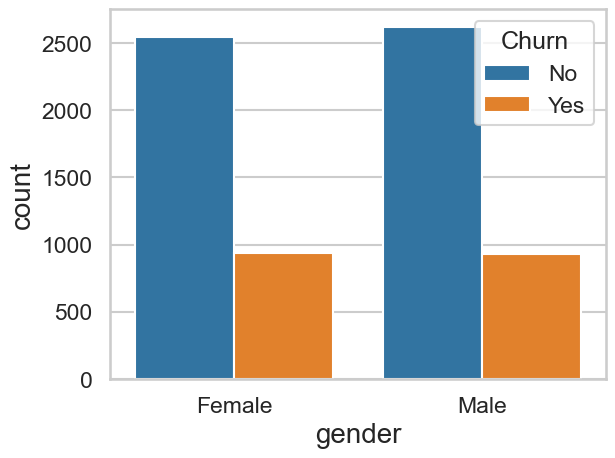

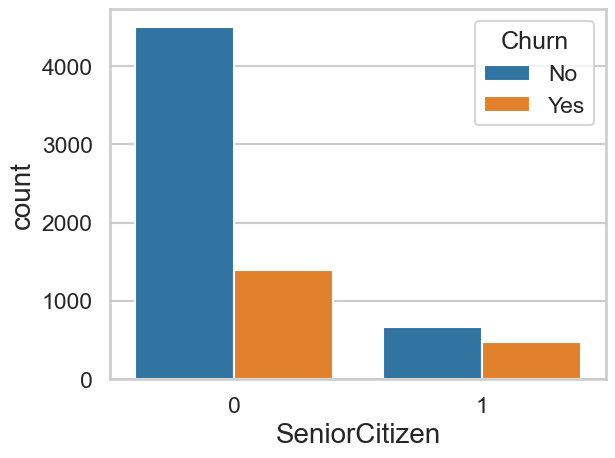

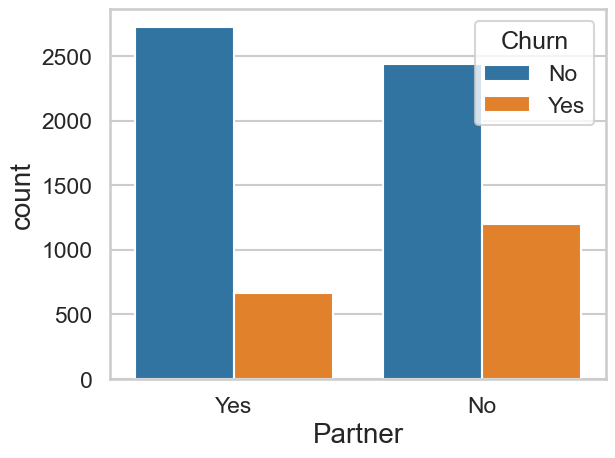

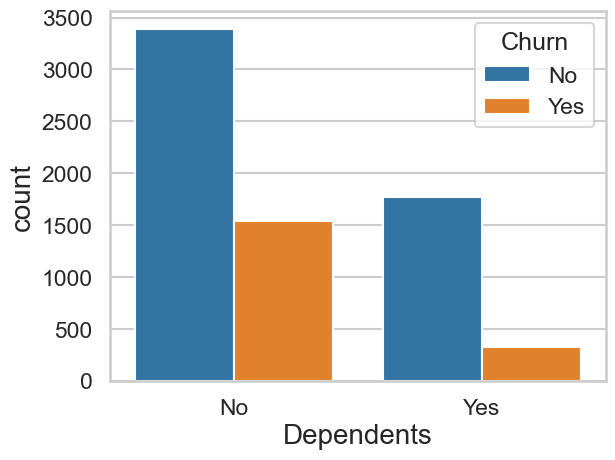

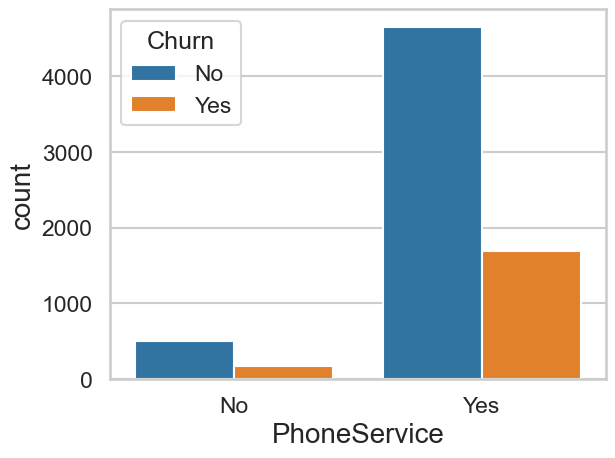

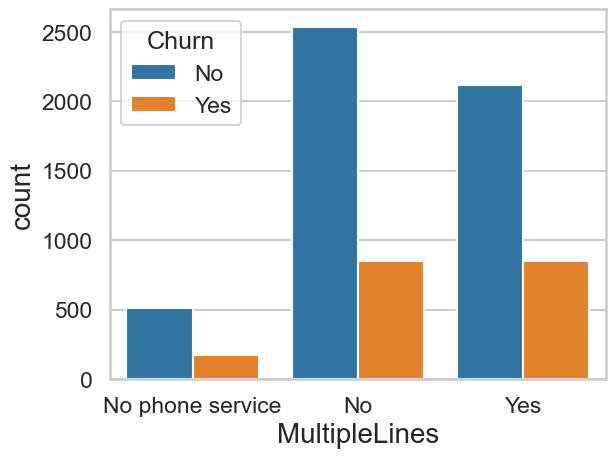

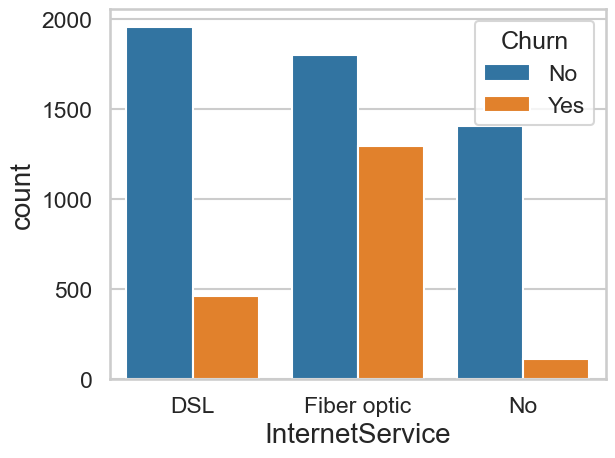

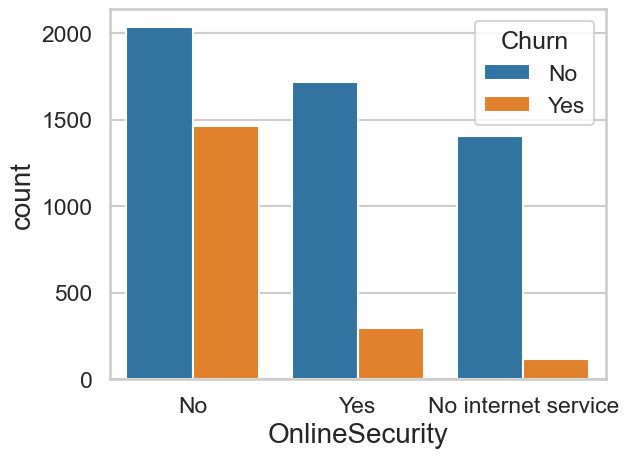

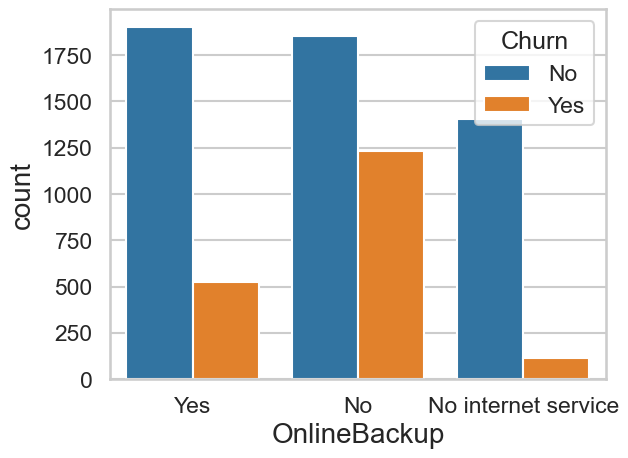

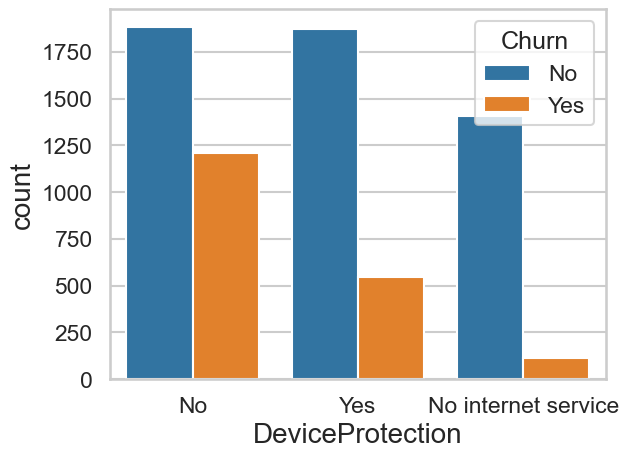

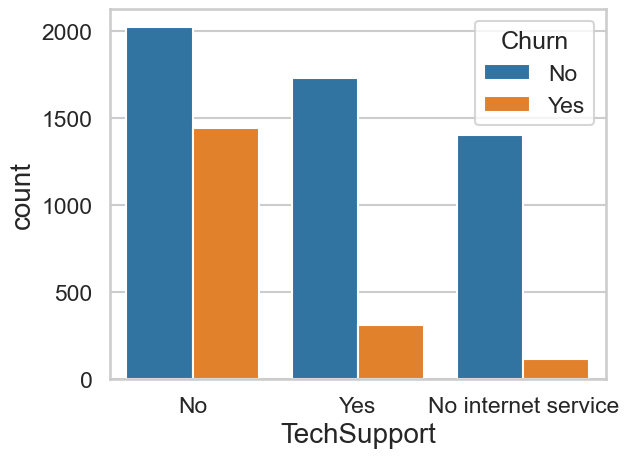

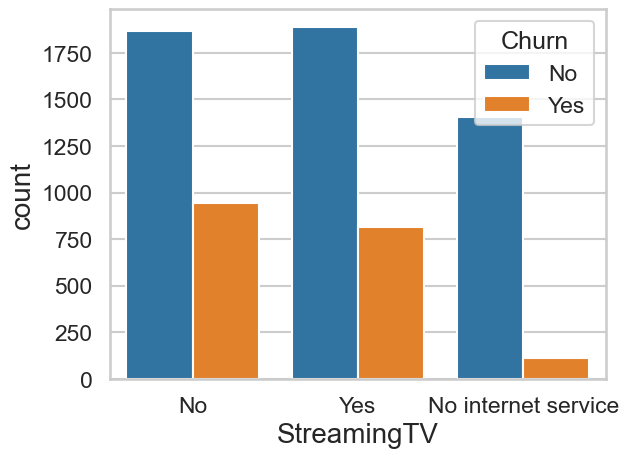

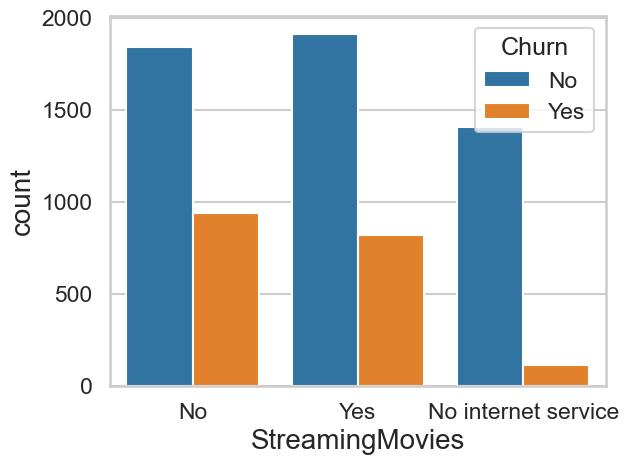

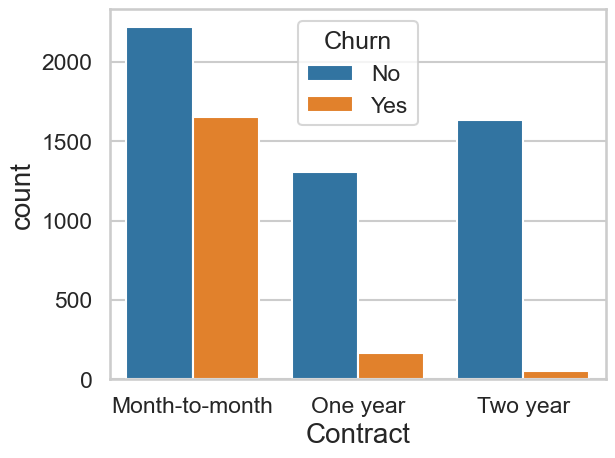

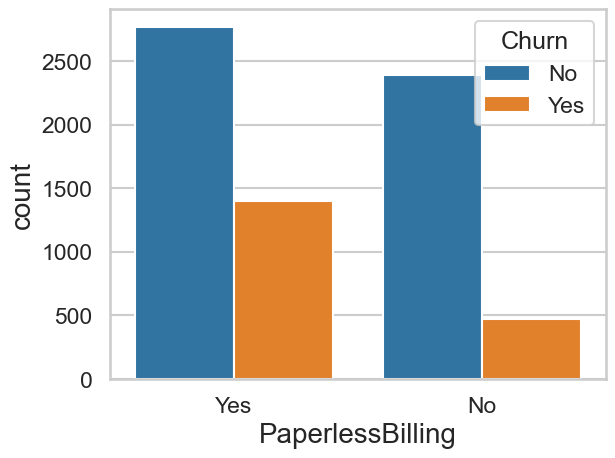

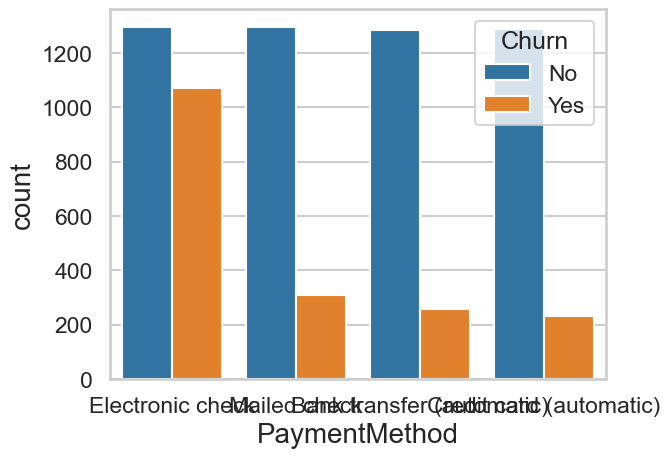

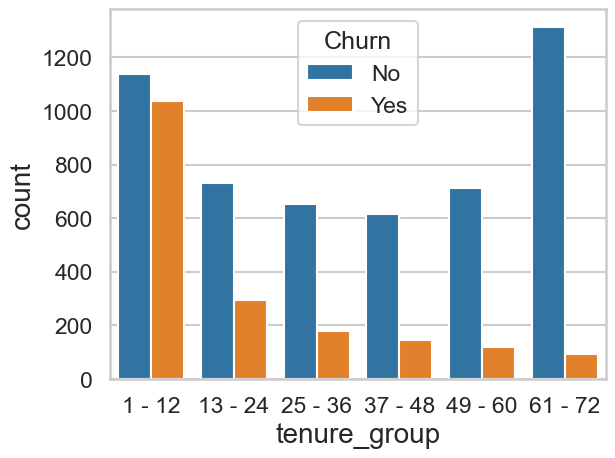

In [162]:
for i, predictor in enumerate(teleco_copy_data.drop(columns=['Churn', 'TotalCharges' ,'MonthlyCharges'])):
    plt.figure(i)
    sns.countplot(data = teleco_copy_data, x=predictor, hue = 'Churn')

In [163]:
teleco_copy_data['Churn'] = np.where(teleco_copy_data.Churn == 'Yes',1,0)

Convert all categorial data into numerical data using one hot encoding

In [164]:
teleco_copy_dummies = pd.get_dummies(teleco_copy_data, dtype=int) #Using dummy trap to reduce computation cost
teleco_copy_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,1,0,0,1,1,0,...,0,0,1,0,1,0,0,0,0,0
1,0,56.95,1889.50,0,0,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,0,53.85,108.15,1,0,1,1,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,0,42.30,1840.75,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70.70,151.65,1,1,0,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0


Relation between monthly charge and total charge

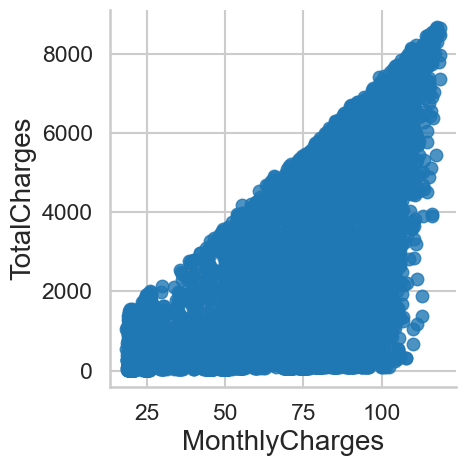

In [165]:
sns.lmplot(data=teleco_copy_dummies, x = 'MonthlyCharges', y = 'TotalCharges', fit_reg = False)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11980\325748374.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(teleco_copy_dummies.MonthlyCharges[(teleco_copy_dummies["Churn"] == 0) ],
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11980\325748374.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(teleco_copy_dummies.MonthlyCharges[(teleco_copy_dummies["Churn"] == 1) ],


Text(0.5, 1.0, 'Monthly charges by churn')

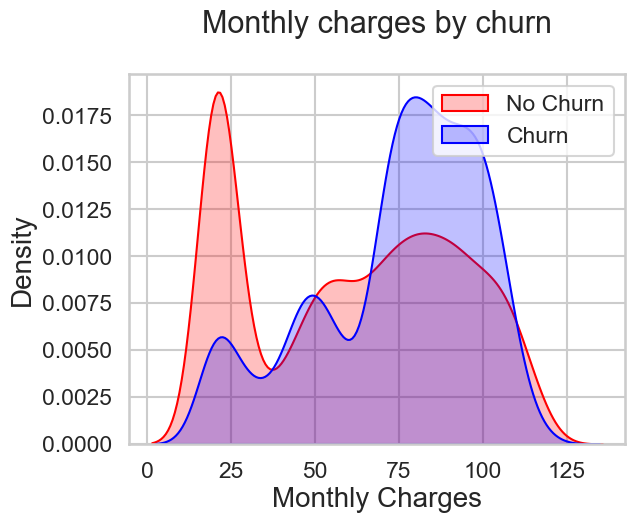

In [166]:
Mth = sns.kdeplot(teleco_copy_dummies.MonthlyCharges[(teleco_copy_dummies["Churn"] == 0) ],
                color="Red", shade = True)
Mth = sns.kdeplot(teleco_copy_dummies.MonthlyCharges[(teleco_copy_dummies["Churn"] == 1) ],
                ax =Mth, color="Blue", shade= True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly charges by churn')

Insight: Churn is high when monthly charges is high

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11980\2694502347.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(teleco_copy_dummies.TotalCharges[(teleco_copy_dummies["Churn"] == 0) ],
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11980\2694502347.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(teleco_copy_dummies.TotalCharges[(teleco_copy_dummies["Churn"] == 1) ],


Text(0.5, 1.0, 'Total charges by churn')

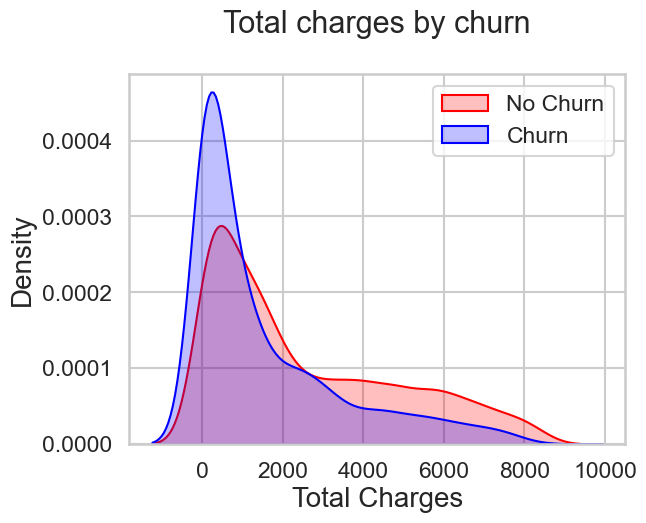

In [167]:
Tot = sns.kdeplot(teleco_copy_dummies.TotalCharges[(teleco_copy_dummies["Churn"] == 0) ],
                color="Red", shade = True)
Tot = sns.kdeplot(teleco_copy_dummies.TotalCharges[(teleco_copy_dummies["Churn"] == 1) ],
                ax =Tot, color="Blue", shade= True)
Tot.legend(["No Churn","Churn"],loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Total Charges')
Tot.set_title('Total charges by churn')

Insight: Churn may be high or low at low Totalcharges which is not helpful

** Surprising insight ** as higher Churn at lower Total Charges

However if we combine the insights of 3 parameters i.e. Tenure, Monthly Charges & Total Charges then the picture is bit clear :- Higher Monthly Charge at lower tenure results into lower Total Charge. Hence, all these 3 factors viz Higher Monthly Charge, Lower tenure and Lower Total Charge are linkd to High Churn.

Correlation of all predictors of churn

<Axes: >

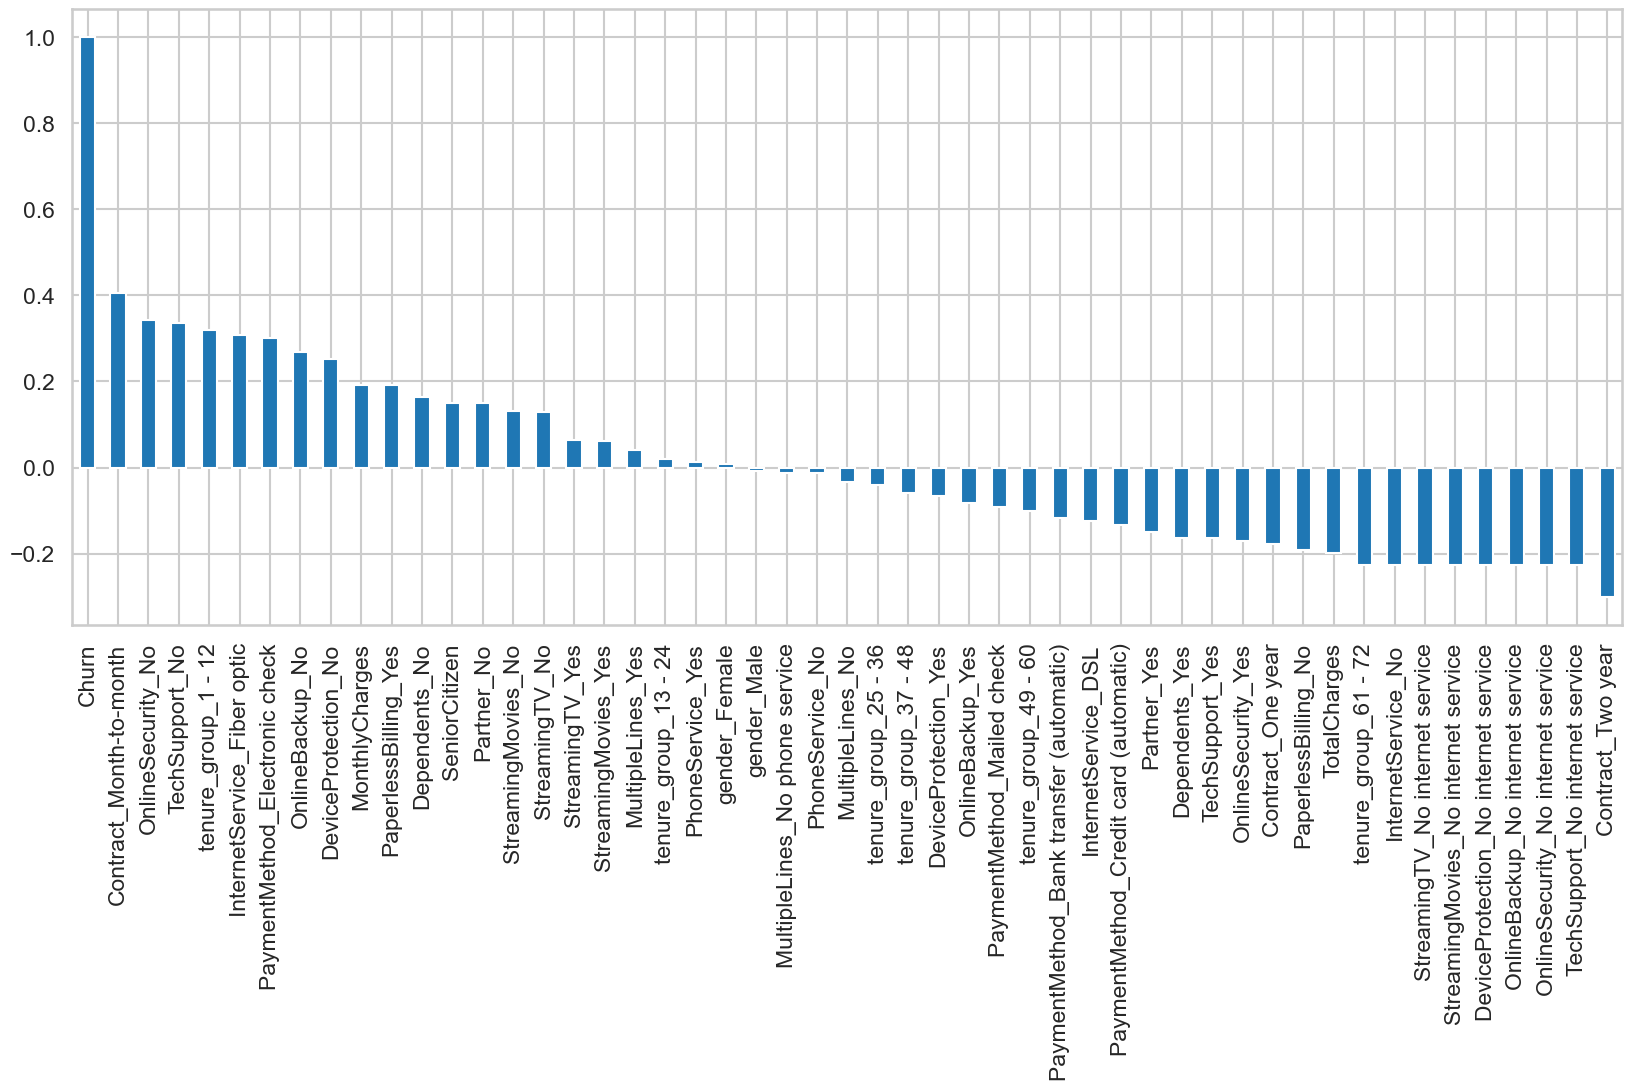

In [168]:
plt.figure(figsize=(20,8))
teleco_copy_dummies.corr()['Churn'].sort_values(ascending = False).plot(kind='bar')

Insights:

HIGH Churn seen in case of Month to month contracts, No online security, No Tech support, First year of subscription and Fibre Optics Internet

LOW Churn is seens in case of Long term contracts, Subscriptions without internet service and The customers engaged for 5+ years

Factors like Gender, Availability of PhoneService and # of multiple lines have alomost NO impact on Churn

This is also evident from the Heatmap(Correlation Matrix) below

<Axes: >

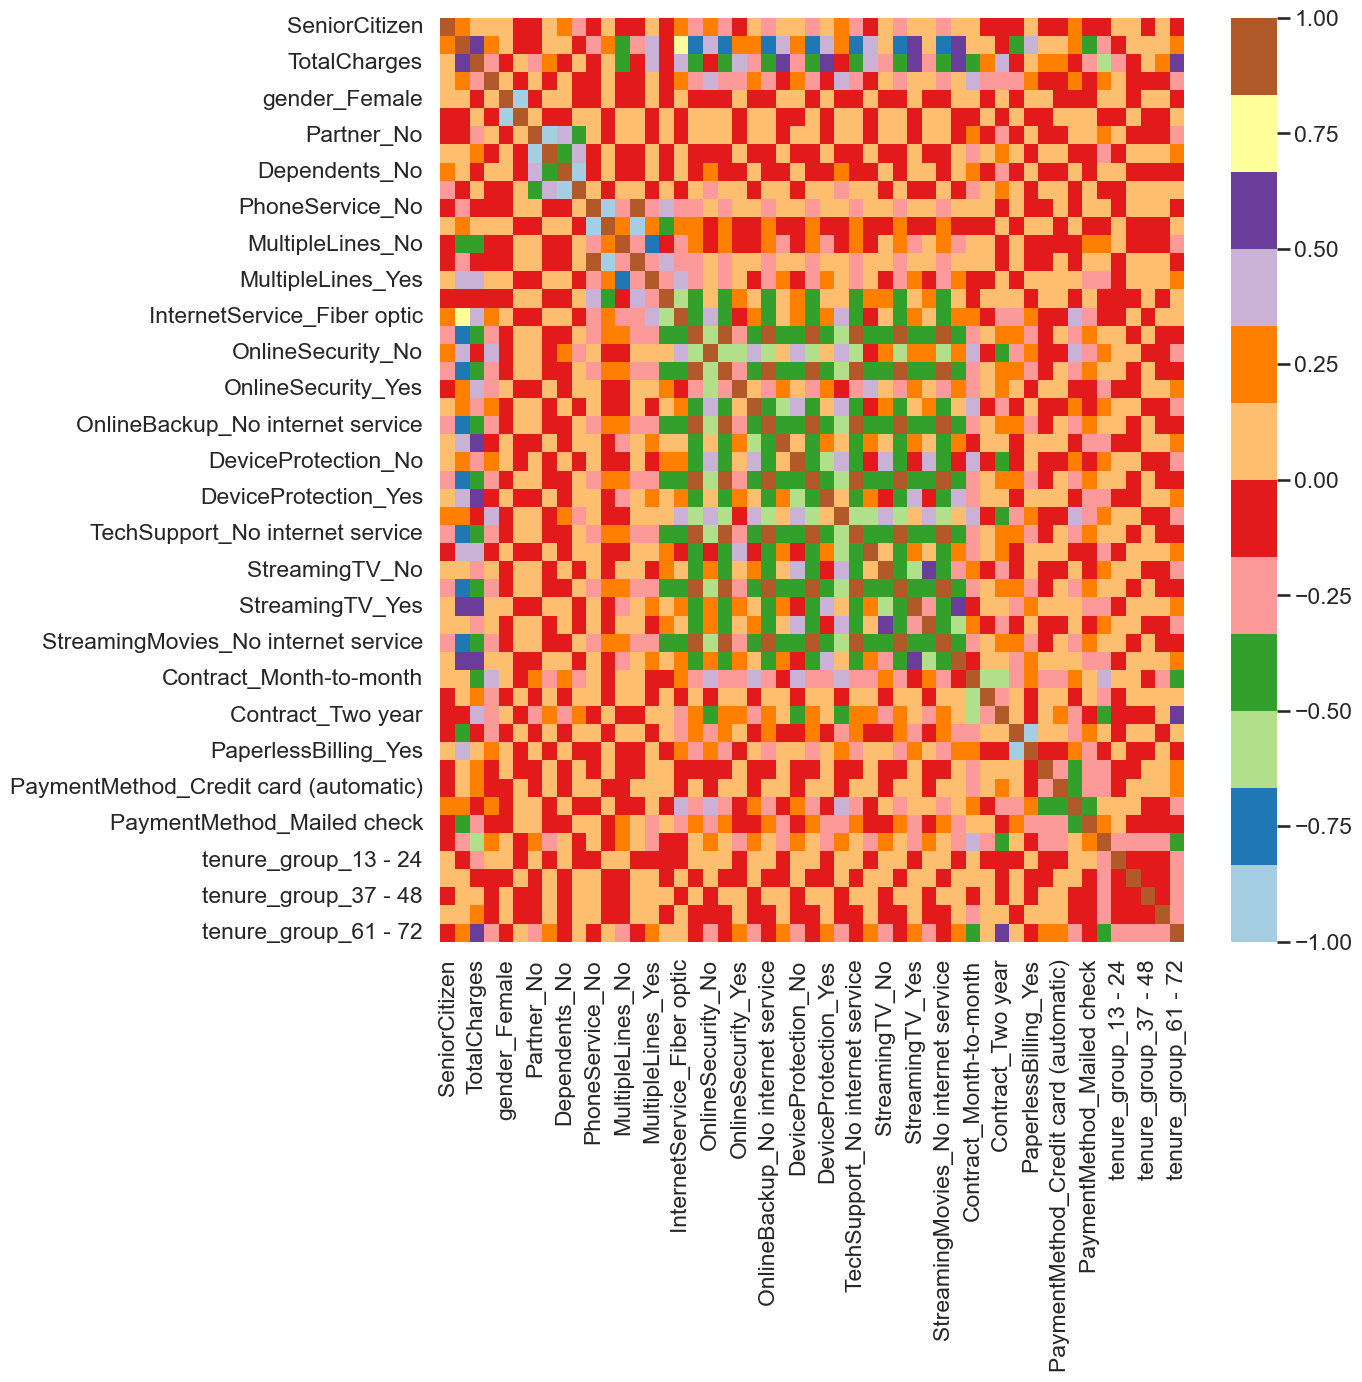

In [169]:
plt.figure(figsize=(12,12))
sns.heatmap(teleco_copy_dummies.corr(), cmap="Paired")

#### Bivariate Analysis

To understand:  
1 Distribution of Gender/Non Gender for Churned Customers  
2 Distribution of PaymentMethod/Contract/Techsupport/SeniorCitizen for Churned Customers  
3 Corelation Between Montly Chages, Churn and Yearly Charges

In [170]:
new_df1_target0=teleco_copy_data.loc[teleco_copy_data["Churn"]==0]
new_df1_target1=teleco_copy_data.loc[teleco_copy_data["Churn"]==1]

In [171]:
def uniplot(df,col,title,hue=None):

    sns.set_style('whitegrid')
    sns.set_context('talk')

    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30

    fig, ax = plt.subplots(figsize=(12,8))
    plt.xticks(rotation=45)
    plt.title(title)

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        hue=hue,
        palette='bright'
    )

    plt.show()

'''def uniplot(df,col,title,hue =None):
    
    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30
    
    
    temp = pd.Series(data = hue)
    fig, ax = plt.subplots()
    width = len(df[col].unique()) + 7 + 4*len(temp.unique())
    fig.set_size_inches(width , 8)
    plt.xticks(rotation=45)
    plt.yscale('log')
    plt.title(title)
    ax = sns.countplot(data = df, x= col, order=df[col].value_counts().index,hue = hue,palette='bright') 
        
    plt.show()'''


'def uniplot(df,col,title,hue =None):\n\n    sns.set_style(\'whitegrid\')\n    sns.set_context(\'talk\')\n    plt.rcParams["axes.labelsize"] = 20\n    plt.rcParams[\'axes.titlesize\'] = 22\n    plt.rcParams[\'axes.titlepad\'] = 30\n\n\n    temp = pd.Series(data = hue)\n    fig, ax = plt.subplots()\n    width = len(df[col].unique()) + 7 + 4*len(temp.unique())\n    fig.set_size_inches(width , 8)\n    plt.xticks(rotation=45)\n    plt.yscale(\'log\')\n    plt.title(title)\n    ax = sns.countplot(data = df, x= col, order=df[col].value_counts().index,hue = hue,palette=\'bright\') \n\n    plt.show()'

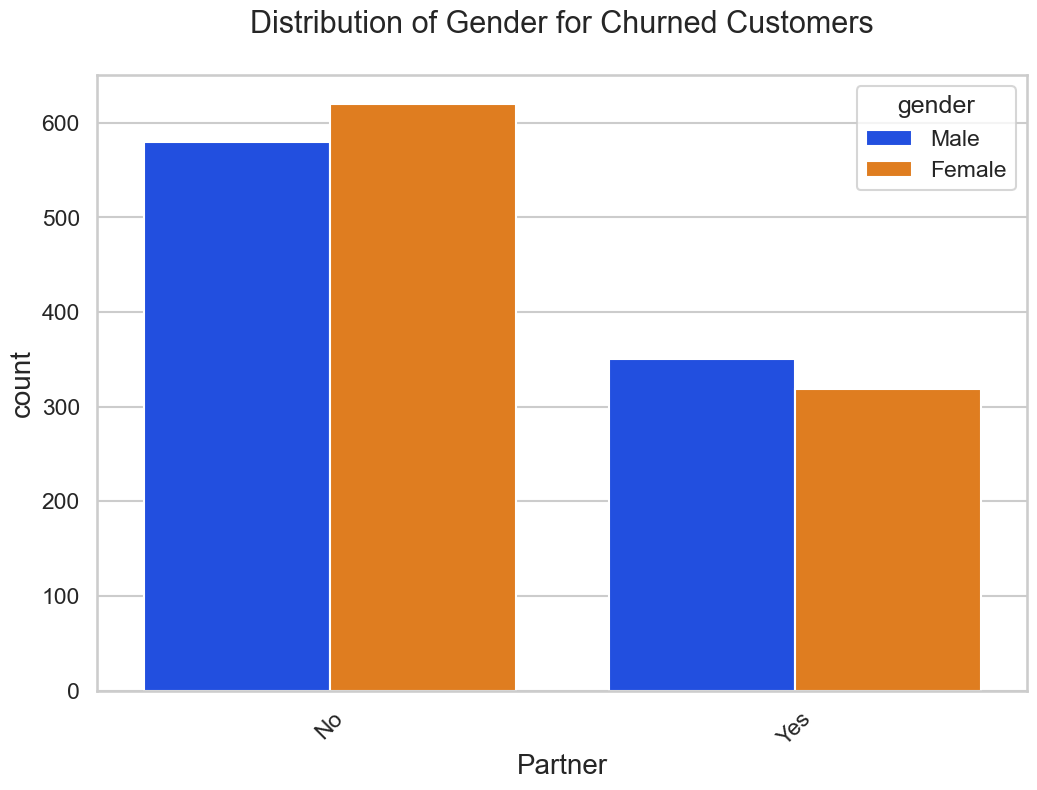

In [172]:
uniplot(new_df1_target1,col='Partner',title='Distribution of Gender for Churned Customers',hue='gender')

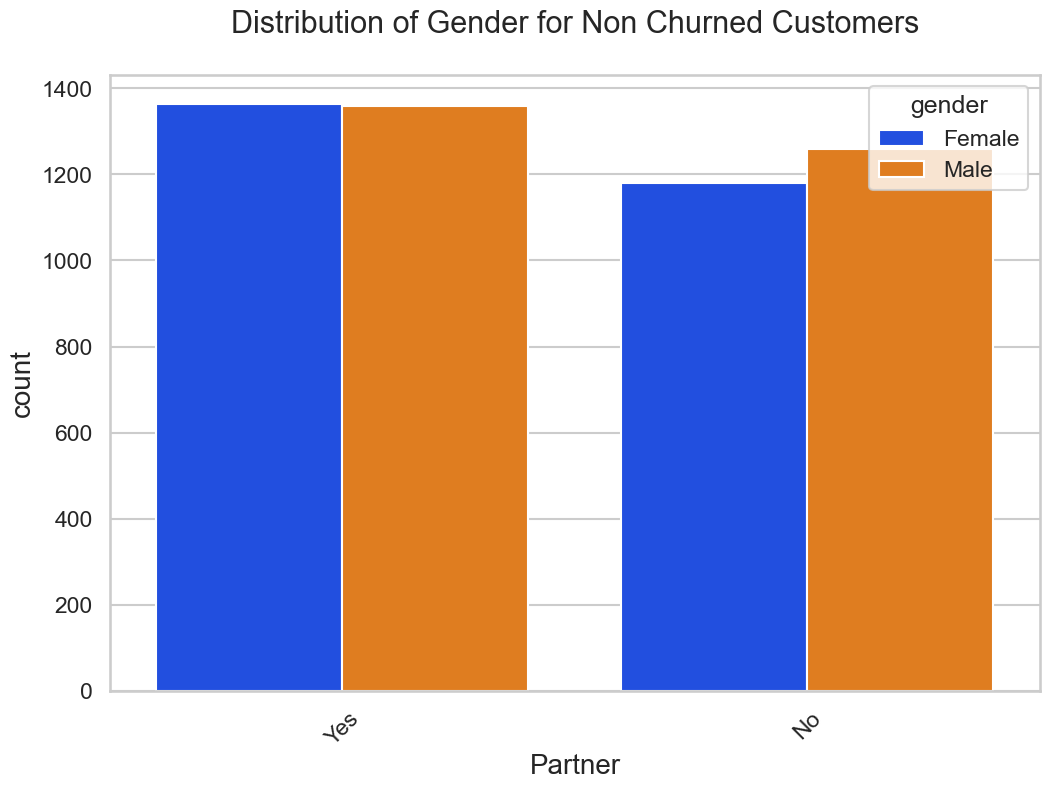

In [173]:
uniplot(new_df1_target0,col='Partner',title='Distribution of Gender for Non Churned Customers',hue='gender')

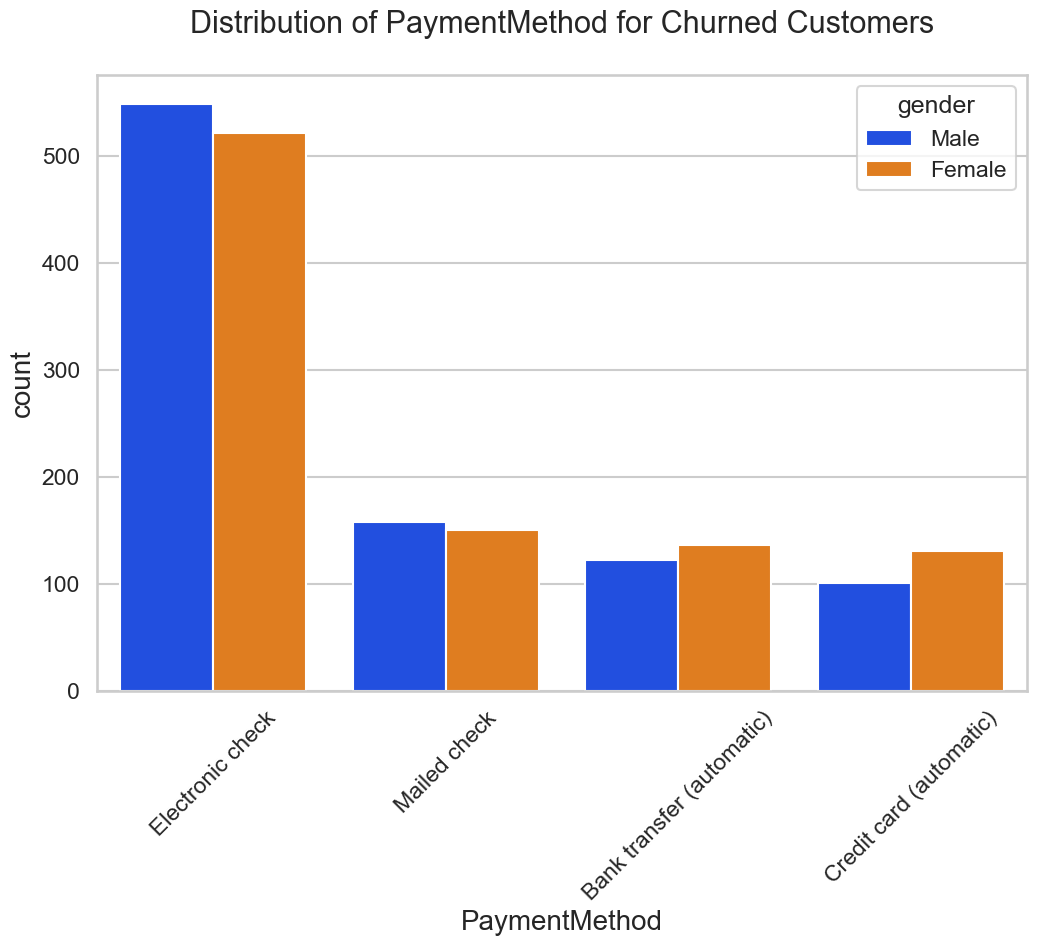

In [174]:
uniplot(new_df1_target1,col='PaymentMethod',title='Distribution of PaymentMethod for Churned Customers',hue='gender')

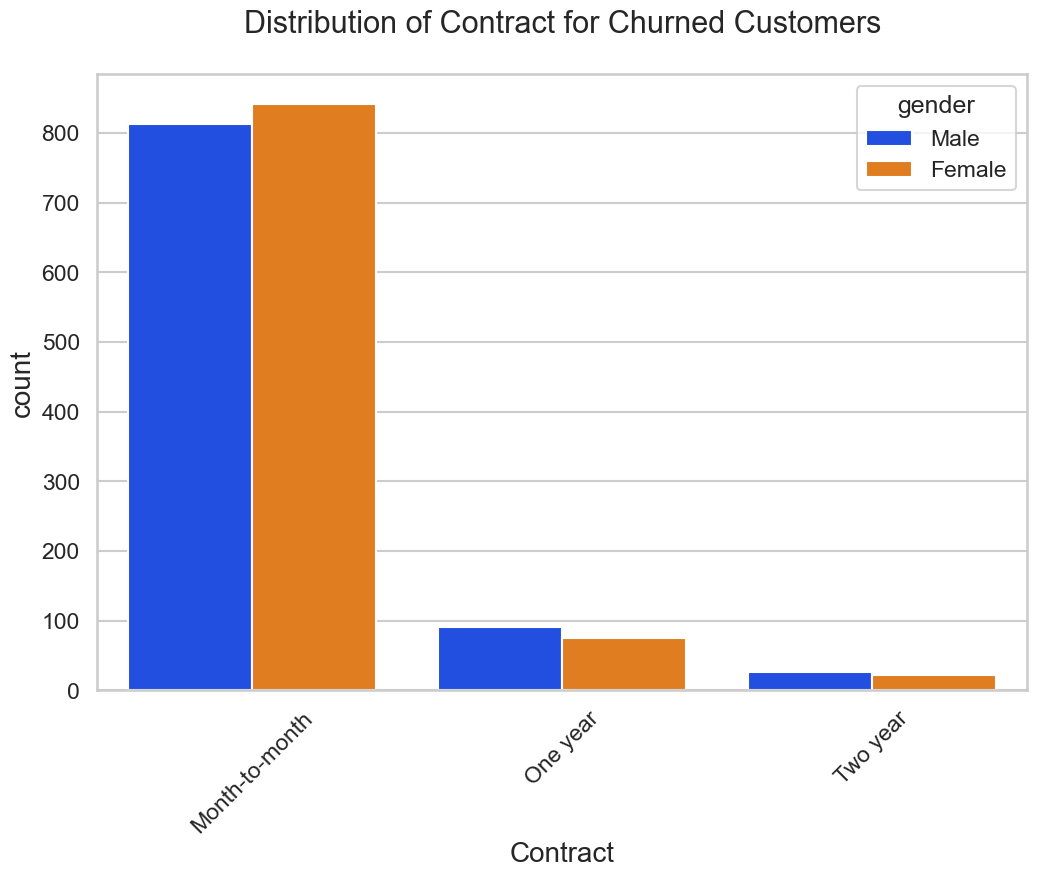

In [175]:
uniplot(new_df1_target1,col='Contract',title='Distribution of Contract for Churned Customers',hue='gender')

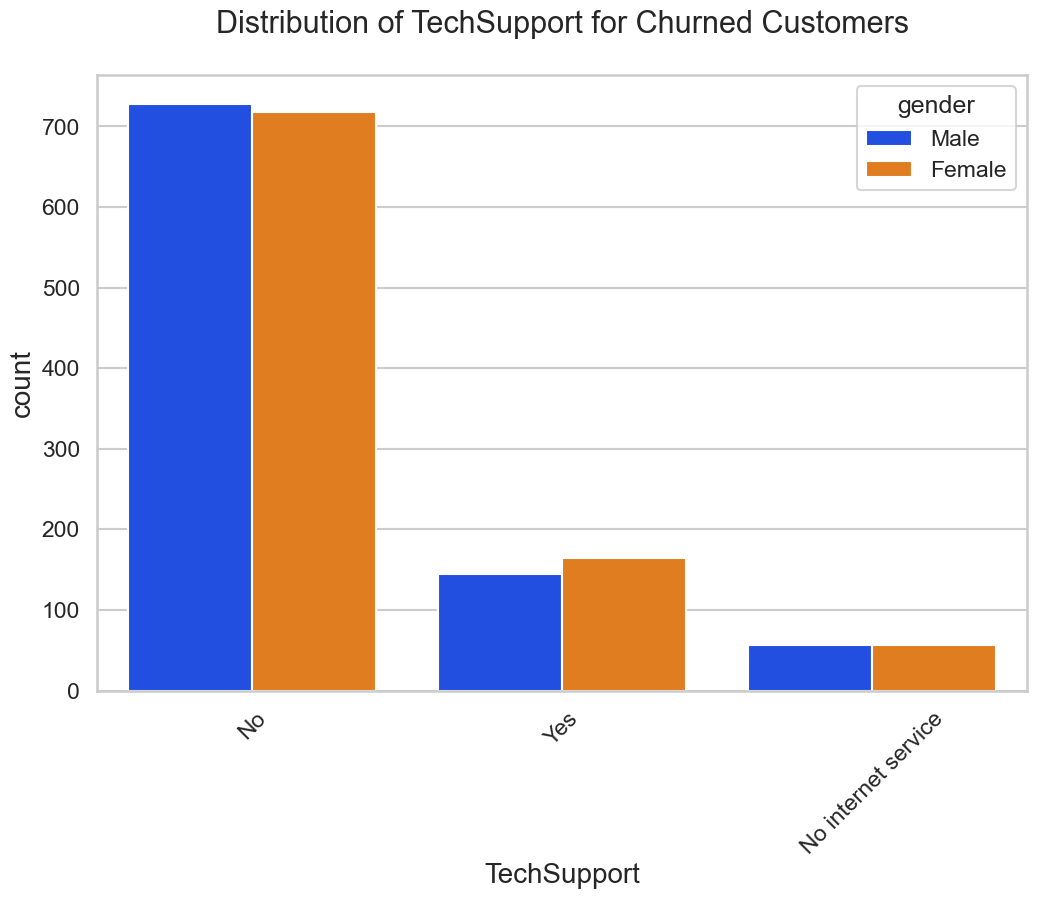

In [176]:

uniplot(new_df1_target1,col='TechSupport',title='Distribution of TechSupport for Churned Customers',hue='gender')

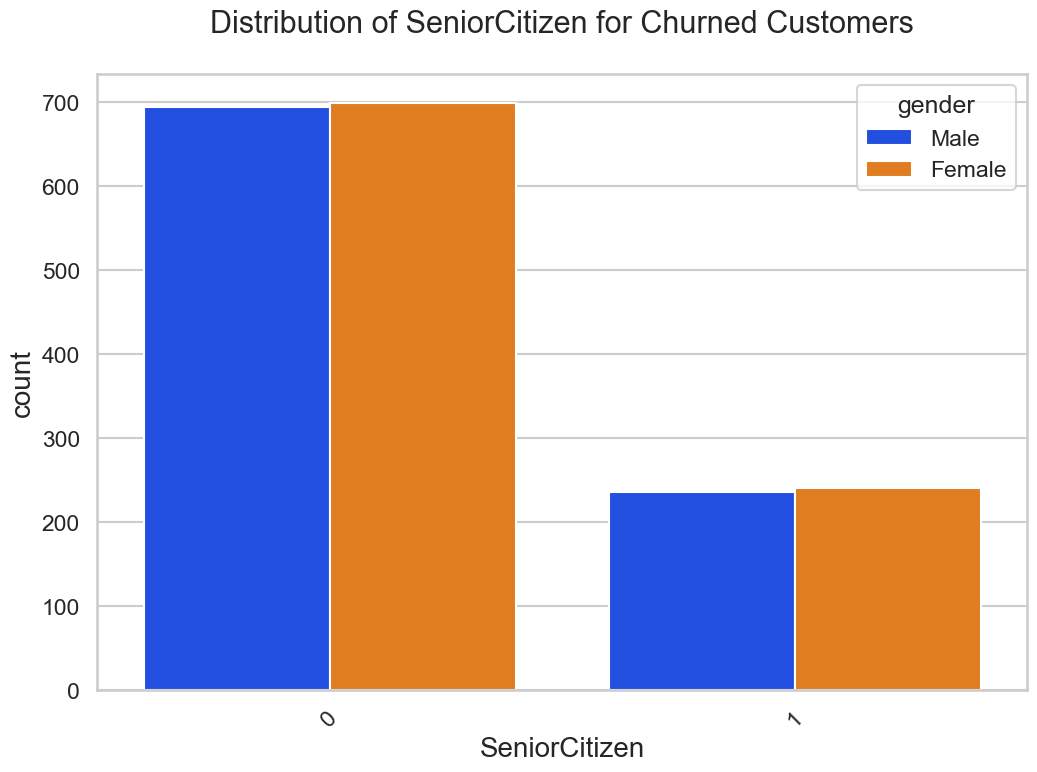

In [177]:
uniplot(new_df1_target1,col='SeniorCitizen',title='Distribution of SeniorCitizen for Churned Customers',hue='gender')

CONCLUSION !

These are some of the quick insights from this exercise:

1. Electronic check medium are the highest churners
2. Contract Type - Monthly customers are more likely to churn because of no contract terms, as they are free to go customers.
3. No Online security, No Tech Support category are high churners
4. Dependants and Partner features indirectly dependent to each other
5. Highly Tenure customers are less likely to churn as they come under loyal customer
6. Gender has  relation with churn prediction
..and more

Non senior Citizens are high churners

In [178]:
teleco_copy_dummies.to_csv('tel_churn.csv')